In [2]:
# Gate: load the two global SHAP tables and show their columns, so the
# plotting cell can be pointed at the right ones.
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
T = ROOT / "outputs" / "tables"

m1 = pd.read_csv(T / "08_m1_global_shap.csv")
m2 = pd.read_csv(T / "08_m2_global_shap.csv")

print("M1 columns:", list(m1.columns), "| rows:", len(m1))
print("M2 columns:", list(m2.columns), "| rows:", len(m2))
print(m1.head(3))

M1 columns: ['Unnamed: 0', 'mean_abs_shap'] | rows: 10
M2 columns: ['Unnamed: 0', 'rank', 'mean_abs_shap', 'family', 'share_%'] | rows: 26
       Unnamed: 0  mean_abs_shap
0  Payment Format       1.245876
1       From Bank       1.003990
2     Amount Paid       0.514667


graph 52.81% | confounded 32.17% of total mass
saved: c:\Fintech-Project\graph_AML_pipeline\outputs\figures\13_shap_displacement.png


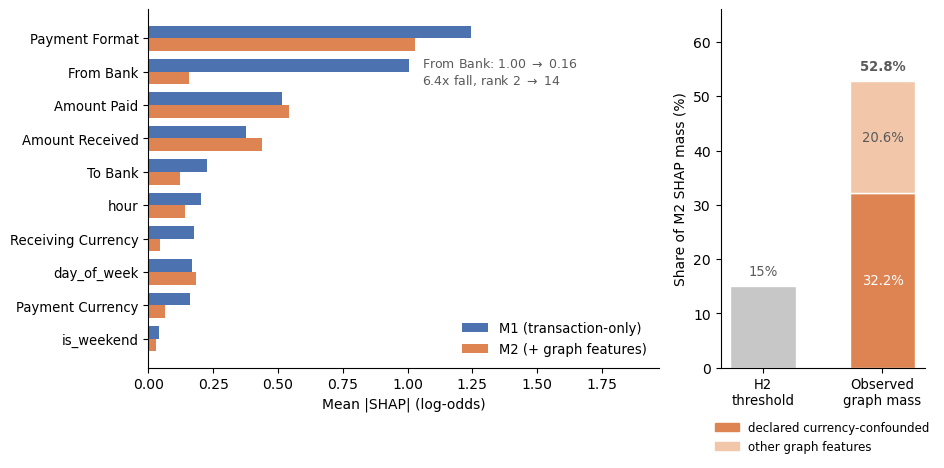

In [3]:
# Figure 1: (A) the ten features both models share, M1 vs M2.
# (B) H2 verdict - observed graph mass against the registered 15% threshold,
# split by the currency-confound declaration.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

FEAT_COL, VAL_COL = "Unnamed: 0", "mean_abs_shap"
BLUE, ORANGE, PALE, GREY, DARK = "#4C72B0", "#DD8452", "#F2C6A8", "#C7C7C7", "#5A5A5A"

s1  = m1.set_index(FEAT_COL)[VAL_COL]
s2  = m2.set_index(FEAT_COL)[VAL_COL]
fam = m2.set_index(FEAT_COL)["family"]

is_graph = fam.str.startswith("graph_")
is_conf  = is_graph & s2.index.str.endswith(
    ("in_weighted", "out_weighted", "net_flow", "pagerank"))

total     = s2.sum()
graph_pct = 100 * s2[is_graph].sum() / total
conf_pct  = 100 * s2[is_conf].sum()  / total

# gates: the figure must reproduce the registered / verified numbers
assert is_graph.sum() == 16 and is_conf.sum() == 8
assert abs(graph_pct - 52.81) < 0.05, f"graph {graph_pct:.2f}"
assert abs(conf_pct  - 32.17) < 0.05, f"conf {conf_pct:.2f}"
print(f"graph {graph_pct:.2f}% | confounded {conf_pct:.2f}% of total mass")

fig, (axA, axB) = plt.subplots(
    1, 2, figsize=(9.6, 4.8), gridspec_kw={"width_ratios": [2.5, 1.0]})

# --- Panel A ------------------------------------------------------------
shared = list(s1.sort_values().index)      # ascending -> largest at top
y, h = np.arange(len(shared)), 0.38
axA.barh(y + h/2, s1.reindex(shared).values, height=h, color=BLUE,
         label="M1 (transaction-only)")
axA.barh(y - h/2, s2.reindex(shared).values, height=h, color=ORANGE,
         label="M2 (+ graph features)")
axA.set_yticks(y); axA.set_yticklabels(shared, fontsize=9.5)
axA.set_xlim(0, s1.max() * 1.58)
axA.set_xlabel("Mean |SHAP| (log-odds)", fontsize=10)
axA.spines[["top", "right"]].set_visible(False)
axA.legend(frameon=False, fontsize=9.5, loc="lower right")

fb = shared.index("From Bank")
axA.text(s1["From Bank"] + 0.05, fb,
         f"From Bank: {s1['From Bank']:.2f} $\\rightarrow$ {s2['From Bank']:.2f}\n"
         "6.4x fall, rank 2 $\\rightarrow$ 14",
         fontsize=9, va="center", color=DARK)

# --- Panel B ------------------------------------------------------------
axB.bar(0, 15, width=0.55, color=GREY, edgecolor="white")
axB.bar(1, conf_pct, width=0.55, color=ORANGE, edgecolor="white")
axB.bar(1, graph_pct - conf_pct, bottom=conf_pct, width=0.55,
        color=PALE, edgecolor="white")

axB.text(0, 17, "15%", ha="center", fontsize=9.5, color=DARK)
axB.text(1, conf_pct/2, f"{conf_pct:.1f}%", ha="center", va="center",
         fontsize=9.5, color="white")
axB.text(1, conf_pct + (graph_pct - conf_pct)/2, f"{graph_pct - conf_pct:.1f}%",
         ha="center", va="center", fontsize=9.5, color=DARK)
axB.text(1, graph_pct + 2, f"{graph_pct:.1f}%", ha="center", fontsize=9.5,
         color=DARK, fontweight="bold")

axB.set_xticks([0, 1])
axB.set_xticklabels(["H2\nthreshold", "Observed\ngraph mass"], fontsize=9.5)
axB.set_ylim(0, 66)
axB.set_ylabel("Share of M2 SHAP mass (%)", fontsize=10)
axB.spines[["top", "right"]].set_visible(False)
axB.legend(handles=[Patch(color=ORANGE, label="declared currency-confounded"),
                    Patch(color=PALE,   label="other graph features")],
           frameon=False, fontsize=8.5, loc="upper center",
           bbox_to_anchor=(0.5, -0.12))

fig.tight_layout()
out = ROOT / "outputs" / "figures" / "13_shap_displacement.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=300, bbox_inches="tight")
print("saved:", out)

          M1_TP  M2_TP  diff  rel_%
budget_k                           
100          37     22   -15  -40.5
250          60     55    -5   -8.3
500          97     84   -13  -13.4
1000        163    130   -33  -20.2
2500        243    208   -35  -14.4
5000        338    316   -22   -6.5
10000       458    451    -7   -1.5
saved: c:\Fintech-Project\graph_AML_pipeline\outputs\figures\13_alert_budget.png


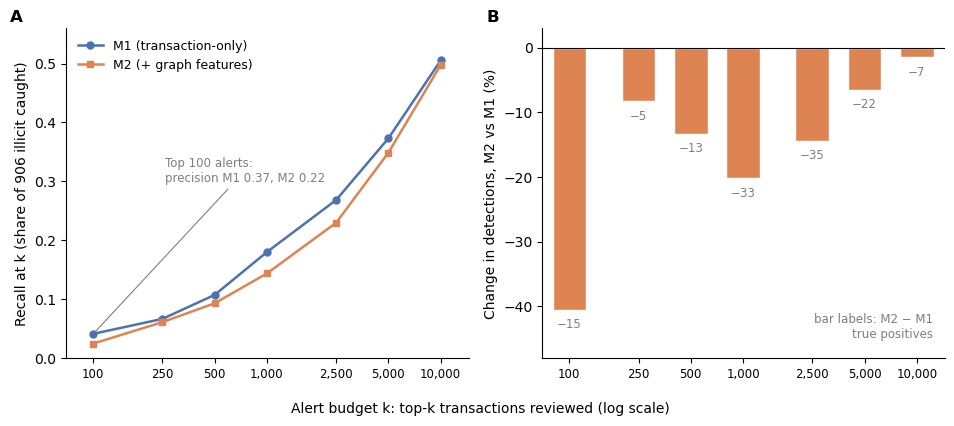

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, NullLocator

BLUE, ORANGE, DARK = "#4C72B0", "#DD8452", "#7F7F7F"   # same palette as Figure 1
N_ILLICIT = 906                                         # test-main illicit (locked)

ab = pd.read_csv(ROOT / "outputs" / "tables" / "12_alert_budget.csv")
m1 = ab[ab.model == "M1"].set_index("budget_k")
m2 = ab[ab.model == "M2"].set_index("budget_k")
k = m1.index.to_numpy()

# gates: the figure must agree with the verified Notebook 12 record (§4H)
assert len(ab) == 14 and (m1.index == m2.index).all()
assert (np.rint(ab.true_positives / ab.recall_at_k) == N_ILLICIT).all()
assert np.allclose(ab.precision_at_k, ab.true_positives / ab.budget_k)
diff = m2.true_positives - m1.true_positives
assert (diff == m2.m2_minus_m1_tp).all() and (diff < 0).all()
assert (m1.loc[100, "true_positives"], m2.loc[100, "true_positives"]) == (37, 22)
rel = 100 * diff / m1.true_positives
print(pd.DataFrame({"M1_TP": m1.true_positives, "M2_TP": m2.true_positives,
                    "diff": diff, "rel_%": rel.round(1)}))

fig, (axA, axB) = plt.subplots(1, 2, figsize=(9.6, 4.3))

# --- Panel A: share of all laundering caught at each queue size ----------
axA.plot(k, m1.recall_at_k, "o-", color=BLUE, lw=1.8, ms=5,
         label="M1 (transaction-only)")
axA.plot(k, m2.recall_at_k, "s-", color=ORANGE, lw=1.8, ms=5,
         label="M2 (+ graph features)")
axA.set_ylabel("Recall at k (share of 906 illicit caught)", fontsize=10)
axA.set_ylim(0, 0.56)
axA.legend(frameon=False, fontsize=9, loc="upper left")
axA.annotate("Top 100 alerts:\nprecision M1 0.37, M2 0.22",
             xy=(100, m1.loc[100, "recall_at_k"]), xytext=(260, 0.30),
             fontsize=8.5, color=DARK,
             arrowprops=dict(arrowstyle="-", lw=0.8, color=DARK))

# --- Panel B: M2's detections relative to M1 at the same budget ----------
# bars are k/1.25 to k*1.25 wide so they look symmetric on a log axis
axB.bar(k / 1.25, rel, width=k * (1.25 - 1 / 1.25), align="edge",
        color=ORANGE, edgecolor="white")
axB.axhline(0, color="black", lw=0.8)
for kk, r, d in zip(k, rel, diff):
    axB.text(kk, r - 1.2, f"{d:+d}".replace("-", "\u2212"), ha="center",
             va="top", fontsize=8.5, color=DARK)
axB.text(0.97, 0.06, "bar labels: M2 \u2212 M1\ntrue positives", transform=axB.transAxes,
         ha="right", fontsize=8.5, color=DARK)
axB.set_ylabel("Change in detections, M2 vs M1 (%)", fontsize=10)
axB.set_ylim(-48, 3)

# shared x-axis styling: real budget values as tick labels, no 10^n
for ax, tag in ((axA, "A"), (axB, "B")):
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(FixedLocator(k))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xticklabels([f"{v:,}" for v in k], fontsize=8.5)
    ax.set_xlim(70, 14500)
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(-0.14, 1.02, tag, transform=ax.transAxes, fontsize=12,
            fontweight="bold")

fig.supxlabel("Alert budget k: top-k transactions reviewed (log scale)",
              fontsize=10, y=0.02)
fig.tight_layout()
out = ROOT / "outputs" / "figures" / "13_alert_budget.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=300, bbox_inches="tight")
print("saved:", out)